# Logistic regression

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
def generate_data(N, seed=42):
    rng = np.random.default_rng(seed)
    n0 = round(N * 0.53)
    n1 = N - n0
    n_left = n0 // 2
    n_mid = n0 - n_left
    left = rng.normal([-5.32, 1.05], [0.47, 0.51], size=(n_left, 2))
    mid = rng.normal([1.47, 1.06], [0.45, 0.48], size=(n_mid, 2))
    right = rng.normal([2.79, 1.01], [0.51, 0.52], size=(n1, 2))
    X = np.vstack([left, mid, right])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

# Generate data
X, y = generate_data(400)
X_train, y_train = X[:200, :], y[:200]
X_test, y_test = X[200:, :], y[200:]

In [3]:
def plot_probabilityMap(model, X, y, yh, plot_means, class_index):
    '''visualizes the output of the applied models with a probability map
    INPUT: 
        'model'-> scikit-learn like instance of classifier models with built-in method 'predict_proba' available
        'X' -> data matrix of size NxD
        'y' -> true class labels
        'yh' -> predicted class labels
        'plot_means' -> only for LDA: adding class means to the plot
        'class_index' -> probability map for class, either '0' or '1'
    
    OUTPUT:
        fig: figure handle of the plot
    '''
    fig = plt.figure(figsize=(8, 4))
    
    tp = (y == yh)  # True Positive
    tp0, tp1 = tp[y == 0], tp[y == 1]
    X0, X1 = X[y == 0], X[y == 1]
    X0_tp, X0_fp = X0[tp0, :], X0[~tp0, :]
    X1_tp, X1_fp = X1[tp1, :], X1[~tp1, :]

    # class 0: true positives vs. false positives
    plt.plot(X0_tp[:, 0], X0_tp[:, 1], 'o', color='red', label="class 0 tp")
    plt.plot(X0_fp[:, 0], X0_fp[:, 1], 'o', color='salmon', label="class 0 fp")  # dark red

    # class 1:
    plt.plot(X1_tp[:, 0], X1_tp[:, 1], 'o', color='blue', label="class 1 tp")
    plt.plot(X1_fp[:, 0], X1_fp[:, 1], 'o', color='lightskyblue', label="class 1 fp")  # dark blue

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    
    # class 0 and 1 : areas
    nx, ny = 200, 100
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, class_index].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap='YlOrBr', shading='auto')
    cbar = plt.colorbar()  # colorbar assigning the probabilities
    cbar.set_label('P(class={})'.format(class_index))
        
    # plot the contour of the 50 probability
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='k')

    # plot class means (only makes sense for LDA)
    if plot_means: 
        plt.plot(model.means_[0][0], model.means_[0][1], 'o', color='black', markersize=10)
        plt.plot(model.means_[1][0], model.means_[1][1], 'o', color='black', markersize=10)

    return fig

## Exercise 1: Inspect a logistic regression model
1. Visualize the training dataset using the class labels. 
2. Train a logistic regression model (`LogisticRegression()`) on the training data. Make sure that you use an "L2-penalty" with $C = 1$.
3. Use the trained model to predict the class labels of the test data and report on the classification performance.
4. Inspect the model with the function `plot_probabilityMap()` and visualize the probability map of class 1 of your trained model using the test dataset as an input.

0.945


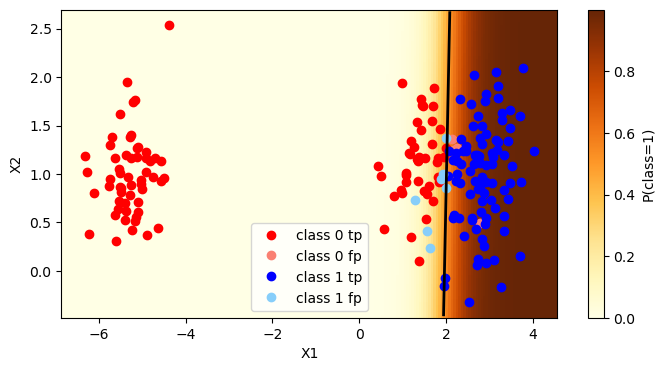

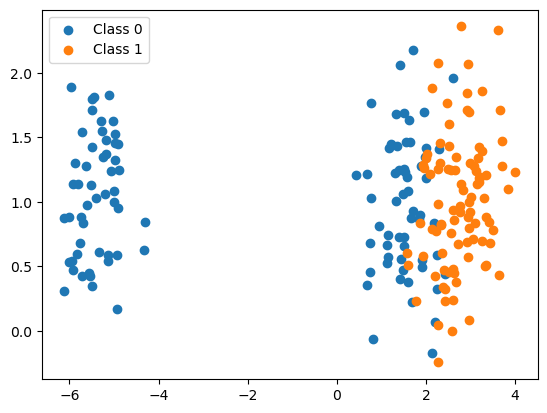

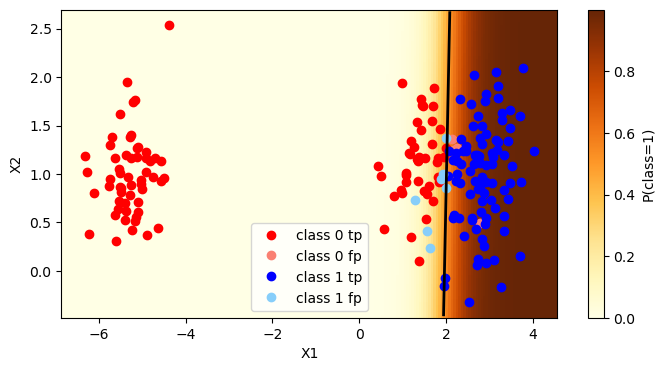

In [5]:
# Answer here
XA = X_train[y_train == 0]
XB = X_train[y_train == 1]
#print(XA.shape)
#print(XB.shape)

plt.scatter(XA[:,0], XA[:,1], label="Class 0")
plt.scatter(XB[:,0], XB[:,1], label="Class 1")
plt.legend()

def logisticR(X_train,y_train):
    model = LogisticRegression(penalty="l2", C=1)
    model.fit(X_train,y_train)
    return model
    
model = logisticR(X_train,y_train)

def calc_predict(X_test,y_test,model):
    
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    return y_pred, accuracy

y_pred, accuracy = calc_predict(X_test,y_test,model)

print(accuracy)

plot_probabilityMap(model, X_test, y_test, y_pred, False, 1)

## Exercise 2: Comparison of logistic regression with LDA 

1. Train an LDA model (`LDA()`) on the training data. Specify the solver to "eigen".
2. Use the trained LDA model to predict the class labels of the test data and report on the classification performance.
3. Apply the function `plot_probabilityMap()` to visualize the probability map of class "1" of your trained LDA model, taking the testdata set as an input. Use the input parameter of the function to visualize the class means.
4. Compare the performance of the logistic regression model with the LDA model. Do you observe a difference in the performance? Can you explain the reason? **Hint:** Compare the two decision boundaries and the assumptions made by the methods.
5. How can you estimate a probability from an LDA classifier? Remember that this is not a probabilistic method by default.

0.775


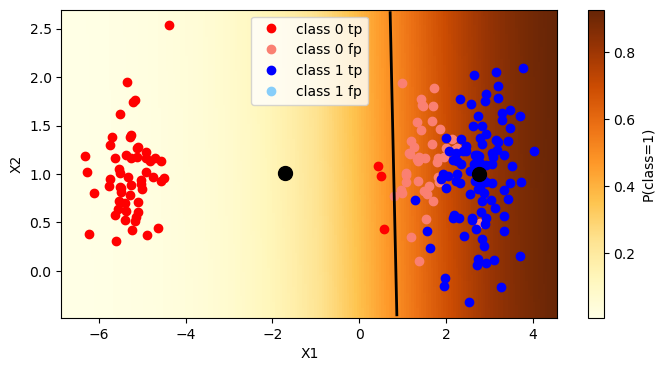

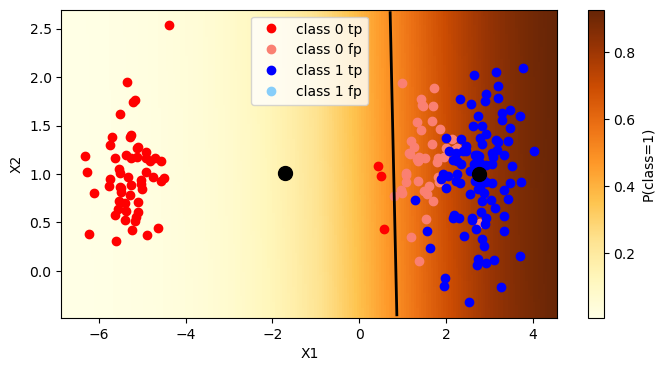

In [7]:
# Answer here
def lda_func(X_train, y_train):
    model = LinearDiscriminantAnalysis(solver="eigen")
    model.fit(X_train, y_train)
    return model

lda_model = lda_func(X_train, y_train)

y_pred_lda = lda_model.predict(X_test)
accuracy = np.mean(y_pred_lda == y_test)
print(accuracy)

plot_probabilityMap(lda_model, X_test, y_test, y_pred_lda, True, 1)

#Logistic regression achieved a higher test accuracy than LDA on this dataset. 
#The difference can be explained by the assumptions of the two methods. 
#LDA assumes that each class follows a Gaussian distribution and that both classes share the same covariance matrix. 
#In this dataset, class 0 consists of two separated clusters, so this assumption is violated.